In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
%pip install yfinance
import yfinance as yf

ticker = 'MSFT'
table = yf.download(ticker, start='2015-01-01', end='2025-05-10')
table


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Collecting yfinance
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.0 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.16.0
    Uninstalling cffi-1.16.0:
      Successfully uninstalled cffi-1.16.0



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2015-01-02,39.767681,40.328987,39.580581,39.682636,27913900
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823685,39.759194,38.730133,39.444523,36447900
2015-01-07,39.316940,39.512547,38.687599,39.104324,29114100
2015-01-08,40.473579,40.609654,39.733677,39.759190,29645200
...,...,...,...,...,...
2025-05-05,432.856232,436.160919,428.827049,429.581285,20136100
2025-05-06,430.017944,434.404377,427.894219,428.916392,15104200


In [4]:
data = table[['Close']]
data

Price,Close
Ticker,MSFT
Date,
2015-01-02,39.767681
2015-01-05,39.401993
2015-01-06,38.823685
2015-01-07,39.316940
2015-01-08,40.473579
...,...
2025-05-05,432.856232
2025-05-06,430.017944


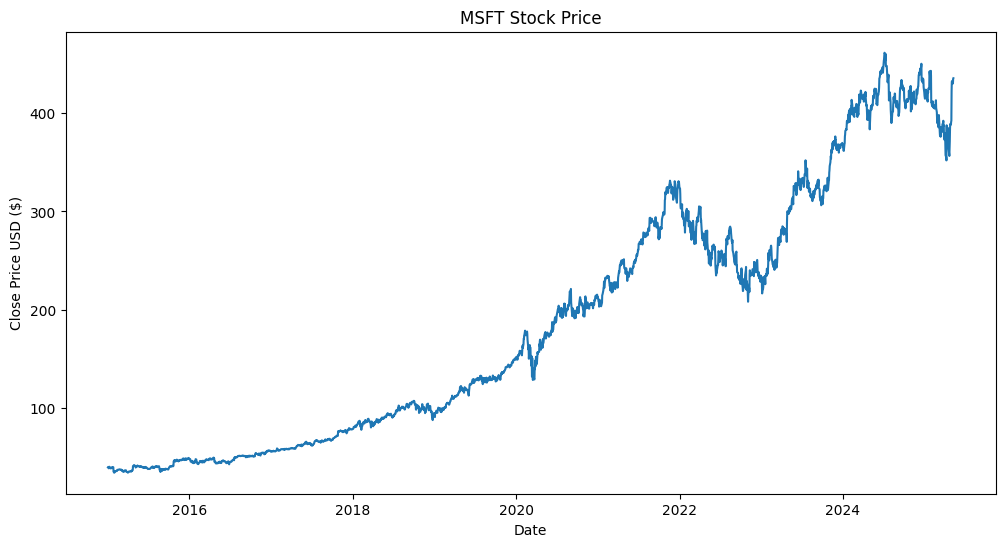

In [5]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title(f"{ticker} Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price USD ($)")
plt.show()

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data

array([[0.01266839],
       [0.01181191],
       [0.01045744],
       ...,
       [0.92677371],
       [0.93797711],
       [0.93927854]])

In [7]:
# ✂️ Split into Train and Test
sequence_length = 120
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - sequence_length:]

In [8]:
# 🧠 Prepare Training Data
X_train, y_train = [], []
for i in range(sequence_length, len(train_data)):
    X_train.append(train_data[i-sequence_length:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [9]:
# 🧪 Prepare Testing Data
X_test, y_test = [], []
for i in range(sequence_length, len(test_data)):
    X_test.append(test_data[i-sequence_length:i, 0])
    y_test.append(test_data[i, 0])

X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# 🔧 Build LSTM Model
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(150, return_sequences=True),
    Dropout(0.5),
    LSTM(100, return_sequences=False),
    Dropout(0.3),
    Dense(64),
    Dense(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

In [11]:
model.fit(X_train, y_train, batch_size=64, epochs=10)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 597ms/step - loss: 0.0093
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 462ms/step - loss: 0.0015
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step - loss: 0.0010
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - loss: 9.0383e-04
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 439ms/step - loss: 8.3887e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 396ms/step - loss: 7.4448e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 398ms/step - loss: 5.6630e-04
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 364ms/step - loss: 6.7613e-04
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - loss: 5.6430e-04
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 508ms/step - loss: 5.8757e-04


In [12]:
# 📈 Predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step


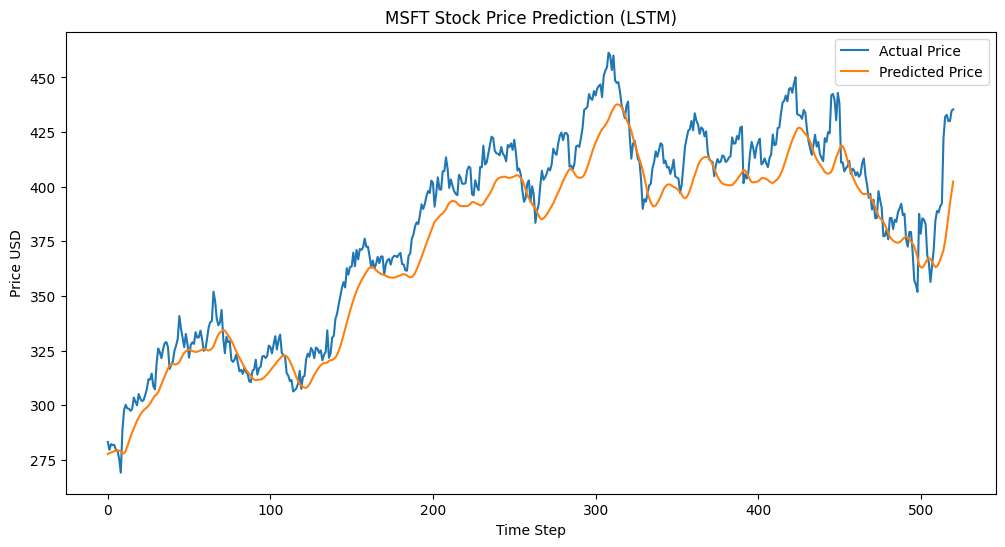

In [13]:
# 📊 Plot Results
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title(f"{ticker} Stock Price Prediction (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Price USD")
plt.legend()
plt.show()

In [14]:
last_sequence = scaled_data[-sequence_length:]

# Reshape last sequence for LSTM input
last_sequence = np.reshape(last_sequence, (1, sequence_length, 1))

# 📈 Predict for the next 10 days
predicted_prices = []
for _ in range(10):  # Predict for the next 10 days
    predicted_price = model.predict(last_sequence)

    # Inverse transform to get the predicted price in the original scale
    predicted_price = scaler.inverse_transform(predicted_price)
    predicted_prices.append(predicted_price[0][0])

    # Reshape the predicted price to (1, 1, 1) and append it
    predicted_price_reshaped = np.reshape(predicted_price, (1, 1, 1))
    last_sequence = np.append(last_sequence[:, 1:, :], predicted_price_reshaped, axis=1)

# Output the predicted prices for the next 10 days
for i, price in enumerate(predicted_prices, 1):
    print(f"Predicted price for day {i}: ${price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Predicted price for day 1: $406.64
Predicted price for day 2: $755.75
Predicted price for day 3: $1024.50
Predicted price for day 4: $1201.29
Predicted price for day 5: $1315.90
Predicted price for day 6: $1391.32
Predicted price for day 7: $1441.79
Predicted price for day 8: $1476.08
Predicted price for day 9: $1499.68
Predicted price for day 10: $1516.14
